In [1]:
import cobra

In [2]:
model_bs= cobra.io.read_sbml_model("/home/buttercup/Desktop/internship/ibsu1147_bigg.xml")


In [3]:
model_bigg = cobra.io.read_sbml_model("/home/buttercup/Desktop/internship/iYO844.xml")

In [4]:
model_bs_witheps = cobra.io.read_sbml_model("/home/buttercup/Desktop/internship/code/ibsu1147_with_eps.xml")

In [16]:
#summary
print(model_bigg.summary())
print(model_bs.summary())   
print(model_bs_witheps.summary())

Objective
1.0 BIOMASS_BS_10 = 0.11796638932239467

Uptake
------
Metabolite    Reaction      Flux  C-Number  C-Flux
     ca2_e    EX_ca2_e 0.0003781         0   0.00%
     fe3_e    EX_fe3_e  0.000407         0   0.00%
  glc__D_e EX_glc__D_e       1.7         6 100.00%
       k_e      EX_k_e   0.08332         0   0.00%
     mg2_e    EX_mg2_e     0.012         0   0.00%
     nh4_e    EX_nh4_e     0.945         0   0.00%
      o2_e     EX_o2_e     5.706         0   0.00%
      pi_e     EX_pi_e    0.1811         0   0.00%
     so4_e    EX_so4_e   0.02009         0   0.00%

Secretion
---------
Metabolite Reaction    Flux  C-Number  C-Flux
     co2_e EX_co2_e  -5.981         1 100.00%
     h2o_e EX_h2o_e   -7.87         0   0.00%
       h_e   EX_h_e -0.7677         0   0.00%

Objective
1.0 bio00006 = 0.11320443977757234

Uptake
------
Metabolite    Reaction      Flux  C-Number  C-Flux
     ca2_e    EX_ca2_e 0.0003377         0   0.00%
     fe3_e    EX_fe3_e 0.0003633         0   0.00%
  glc_

In [5]:
#setting exchange values to be the same for both models:
medium_bigg= model_bigg.medium
print(medium_bigg)
model_bs.medium= medium_bigg
model_bs_witheps.medium= medium_bigg

{'EX_fe3_e': 999999.0, 'EX_glc__D_e': 1.7, 'EX_ca2_e': 999999.0, 'EX_so4_e': 5.0, 'EX_co2_e': 999999.0, 'EX_h2o_e': 999999.0, 'EX_h_e': 999999.0, 'EX_k_e': 999999.0, 'EX_mg2_e': 999999.0, 'EX_na1_e': 999999.0, 'EX_nh4_e': 5.0, 'EX_o2_e': 999999.0, 'EX_pi_e': 5.0}


In [ ]:

solution = model_bs.optimize()
solution_bigg = model_bigg.optimize()
print(solution)
print(solution_bigg)
solution = model_bs_witheps.optimize()
print(solution.objective_value)


<Solution 0.113 at 0x762202c2c180>
<Solution 0.118 at 0x762202c2c8a0>


In [24]:
model_bigg.reactions.EX_glc__D_e.bounds

(-1.7, 999999.0)

In [8]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [14]:
uptake=np.arange(0.1, 10.1, 0.1) # Glucose uptake rates from 0.1 to 10 mmol/gDW/h
uptake=uptake.tolist()
df=pd.DataFrame(columns=['glucose_uptake_mmol_gDW_h','oxygen_uptake_mmol_gDW_h'])
df['glucose_uptake_mmol_gDW_h'] = uptake
df['oxygen_uptake_mmol_gDW_h'] = uptake
def growth_uptake(model,rxn):
    model_name=str(model)
    rxn_name=rxn.id
    for rate in uptake:
        with model:  
            rxn.lower_bound = -rate
            rxn.upper_bound = -rate
            sol = model.optimize()
            growth = sol.objective_value if sol.status == "optimal" else None
            df.at[uptake.index(rate),model_name+"_"+rxn_name+"_growth_rate_1_h"] = growth
            df.at[uptake.index(rate),"status"] = sol.status
    print(df)
    df.to_csv("growth_vs_glucose.csv", index=False)

        

In [15]:

growth_uptake(model_bs,rxn=model_bs.reactions.get_by_id("EX_glc__D_e"))
growth_uptake(model_bigg,rxn=model_bigg.reactions.get_by_id("EX_glc__D_e"))
growth_uptake(model_bs_witheps,rxn=model_bs_witheps.reactions.get_by_id("EX_glc__D_e"))

/home/buttercup/miniconda3/envs/gems311/lib/python3.13/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/buttercup/miniconda3/envs/gems311/lib/python3.13/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


    glucose_uptake_mmol_gDW_h  oxygen_uptake_mmol_gDW_h  \
0                         0.1                       0.1   
1                         0.2                       0.2   
2                         0.3                       0.3   
3                         0.4                       0.4   
4                         0.5                       0.5   
..                        ...                       ...   
95                        9.6                       9.6   
96                        9.7                       9.7   
97                        9.8                       9.8   
98                        9.9                       9.9   
99                       10.0                      10.0   

   ibsu1147_bigg_EX_glc__D_e_growth_rate_1_h      status  
0                                       None  infeasible  
1                                       None  infeasible  
2                                       None  infeasible  
3                                   0.004253     optima

/home/buttercup/miniconda3/envs/gems311/lib/python3.13/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/buttercup/miniconda3/envs/gems311/lib/python3.13/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


    glucose_uptake_mmol_gDW_h  oxygen_uptake_mmol_gDW_h  \
0                         0.1                       0.1   
1                         0.2                       0.2   
2                         0.3                       0.3   
3                         0.4                       0.4   
4                         0.5                       0.5   
..                        ...                       ...   
95                        9.6                       9.6   
96                        9.7                       9.7   
97                        9.8                       9.8   
98                        9.9                       9.9   
99                       10.0                      10.0   

   ibsu1147_bigg_EX_glc__D_e_growth_rate_1_h      status  \
0                                       None  infeasible   
1                                       None  infeasible   
2                                       None  infeasible   
3                                   0.004253     op

/home/buttercup/miniconda3/envs/gems311/lib/python3.13/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/buttercup/miniconda3/envs/gems311/lib/python3.13/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


    glucose_uptake_mmol_gDW_h  oxygen_uptake_mmol_gDW_h  \
0                         0.1                       0.1   
1                         0.2                       0.2   
2                         0.3                       0.3   
3                         0.4                       0.4   
4                         0.5                       0.5   
..                        ...                       ...   
95                        9.6                       9.6   
96                        9.7                       9.7   
97                        9.8                       9.8   
98                        9.9                       9.9   
99                       10.0                      10.0   

   ibsu1147_bigg_EX_glc__D_e_growth_rate_1_h      status  \
0                                       None  infeasible   
1                                       None  infeasible   
2                                       None  infeasible   
3                                   0.004253     op

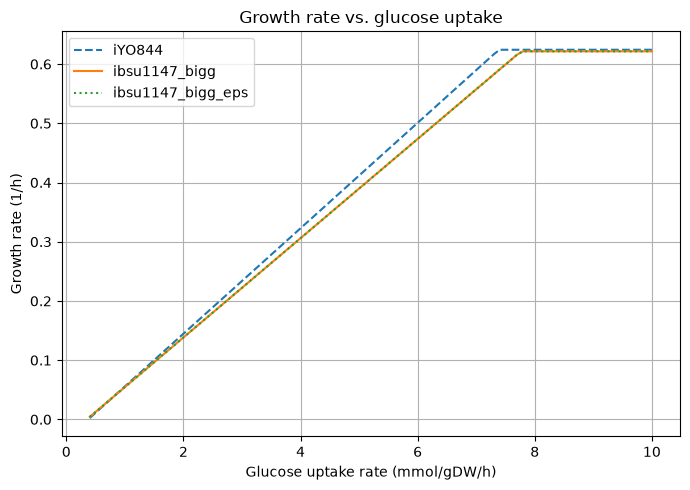

In [16]:

# Plot
plt.figure(figsize=(7, 5))
plt.plot(df["glucose_uptake_mmol_gDW_h"], df["iYO844_EX_glc__D_e_growth_rate_1_h"], linestyle="dashed")
plt.plot(df["glucose_uptake_mmol_gDW_h"], df["ibsu1147_bigg_EX_glc__D_e_growth_rate_1_h"], linestyle="solid")
plt.plot(df["glucose_uptake_mmol_gDW_h"], df["ibsu1147_bigg_eps_EX_glc__D_e_growth_rate_1_h"], linestyle="dotted")
plt.legend(["iYO844", "ibsu1147_bigg", "ibsu1147_bigg_eps"])
plt.xlabel("Glucose uptake rate (mmol/gDW/h)")
plt.ylabel("Growth rate (1/h)")
plt.title("Growth rate vs. glucose uptake")
plt.grid(True)
plt.tight_layout()
plt.savefig("growth_vs_glucose.png", dpi=150)
plt.show()

In [17]:
growth_uptake(model_bs,rxn=model_bs.reactions.get_by_id("EX_o2_e"))
growth_uptake(model_bigg,rxn=model_bigg.reactions.get_by_id("EX_o2_e"))
growth_uptake(model_bs_witheps,rxn=model_bs_witheps.reactions.get_by_id("EX_o2_e"))

    glucose_uptake_mmol_gDW_h  oxygen_uptake_mmol_gDW_h  \
0                         0.1                       0.1   
1                         0.2                       0.2   
2                         0.3                       0.3   
3                         0.4                       0.4   
4                         0.5                       0.5   
..                        ...                       ...   
95                        9.6                       9.6   
96                        9.7                       9.7   
97                        9.8                       9.8   
98                        9.9                       9.9   
99                       10.0                      10.0   

   ibsu1147_bigg_EX_glc__D_e_growth_rate_1_h   status  \
0                                       None  optimal   
1                                       None  optimal   
2                                       None  optimal   
3                                   0.004253  optimal   
4     

/home/buttercup/miniconda3/envs/gems311/lib/python3.13/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/buttercup/miniconda3/envs/gems311/lib/python3.13/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


    glucose_uptake_mmol_gDW_h  oxygen_uptake_mmol_gDW_h  \
0                         0.1                       0.1   
1                         0.2                       0.2   
2                         0.3                       0.3   
3                         0.4                       0.4   
4                         0.5                       0.5   
..                        ...                       ...   
95                        9.6                       9.6   
96                        9.7                       9.7   
97                        9.8                       9.8   
98                        9.9                       9.9   
99                       10.0                      10.0   

   ibsu1147_bigg_EX_glc__D_e_growth_rate_1_h      status  \
0                                       None  infeasible   
1                                       None  infeasible   
2                                       None  infeasible   
3                                   0.004253  infea

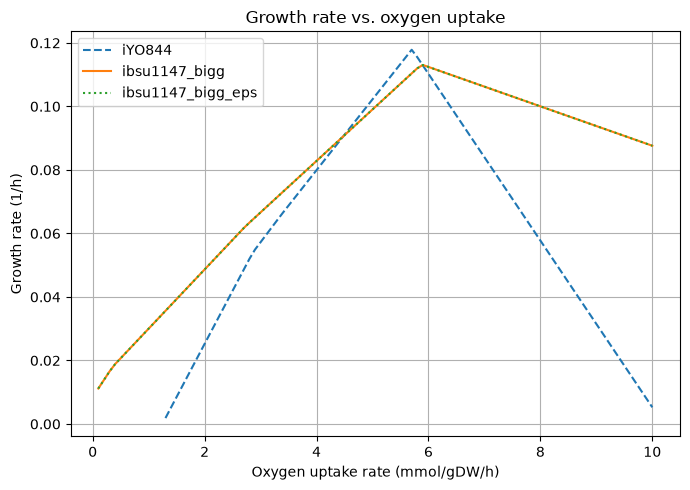

In [18]:

# Plot
plt.figure(figsize=(7, 5))
plt.plot(df["oxygen_uptake_mmol_gDW_h"], df["iYO844_EX_o2_e_growth_rate_1_h"], linestyle="dashed")
plt.plot(df["oxygen_uptake_mmol_gDW_h"], df["ibsu1147_bigg_EX_o2_e_growth_rate_1_h"], linestyle="solid")
plt.plot(df["oxygen_uptake_mmol_gDW_h"], df["ibsu1147_bigg_eps_EX_o2_e_growth_rate_1_h"], linestyle="dotted")
plt.legend(["iYO844", "ibsu1147_bigg", "ibsu1147_bigg_eps"])
plt.xlabel("Oxygen uptake rate (mmol/gDW/h)")
plt.ylabel("Growth rate (1/h)")
plt.title("Growth rate vs. oxygen uptake")
plt.grid(True)
plt.tight_layout()
plt.savefig("growth_vs_oxygen.png", dpi=150)
plt.show()

/home/buttercup/miniconda3/envs/gems311/lib/python3.13/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Saved long-format grid to phpp_data.csv (1681 rows)
Saved grid arrays to phpp_data.npz
Saved long-format grid to phpp_data.csv (1681 rows)
Saved grid arrays to phpp_data.npz
Saved plot to phpp_comparison.png


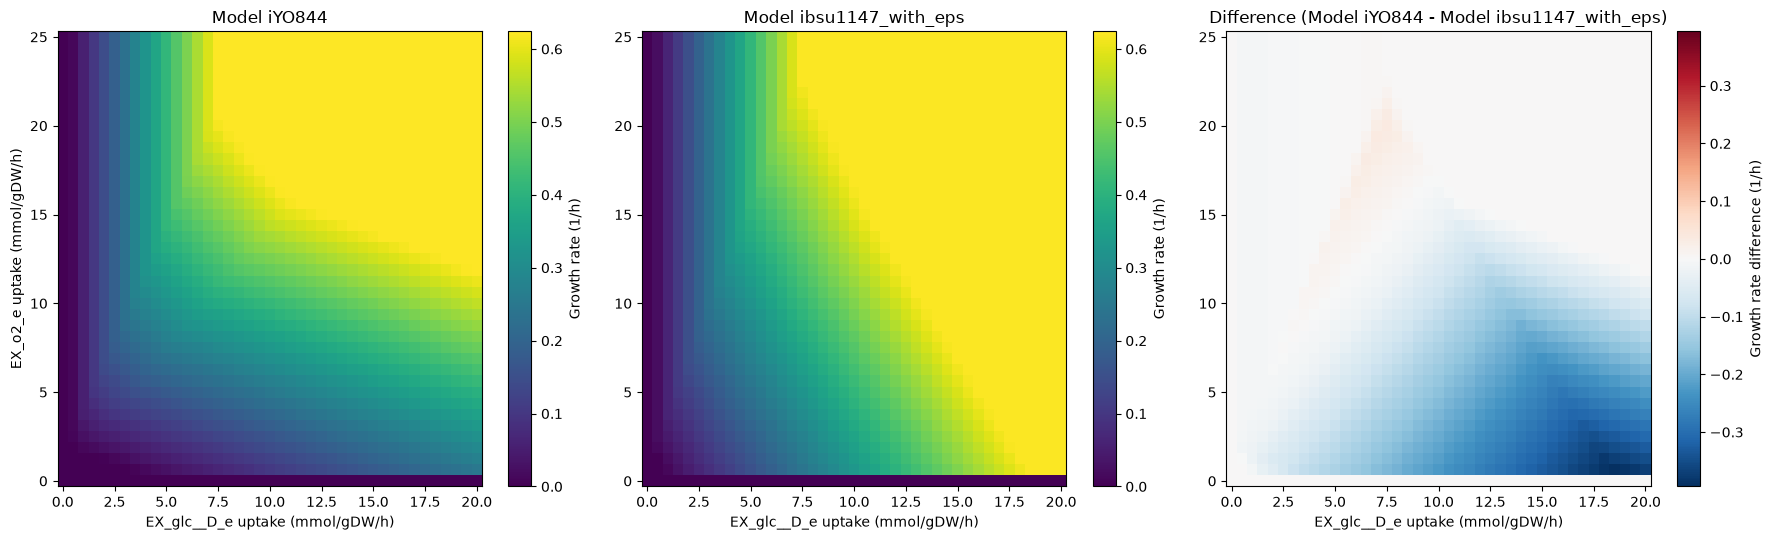

In [ ]:
"""
Compare Phenotype Phase Planes between two models on a common,
identical (carbon uptake, oxygen uptake) grid.
"""

import cobra
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------- CONFIG ---------------------------------- #
MODEL_A_PATH = "/home/buttercup/Desktop/internship/iYO844.xml"
MODEL_B_PATH = "/home/buttercup/Desktop/internship/code/ibsu1147_with_eps.xml"
MODEL_A_LABEL = "Model iYO844"
MODEL_B_LABEL = "Model ibsu1147_with_eps"

CARBON_RXN = "EX_glc__D_e"
OXYGEN_RXN = "EX_o2_e"

# ONE shared grid used for BOTH models -- pick a range that is physiologically
# meaningful for both (e.g. covers each model's feasible range; points beyond
# a model's true capability will just come back infeasible/zero growth,
# which is fine and still comparable).
CARBON_RANGE = np.linspace(-20, 0, 41)
OXYGEN_RANGE = np.linspace(-25, 0, 41)

OUTPUT_FIG = "phpp_comparison.png"
# ------------------------------------------------------------------------ #


def load_model(path):
    if path.endswith(".json"):
        return cobra.io.load_json_model(path)
    elif path.endswith(".mat"):
        return cobra.io.load_matlab_model(path)
    else:
        return cobra.io.read_sbml_model(path)


def run_phpp(model, carbon_rxn_id, oxygen_rxn_id, carbon_range, oxygen_range):
    growth = np.zeros((len(oxygen_range), len(carbon_range)))

    carbon_rxn = model.reactions.get_by_id(carbon_rxn_id)
    oxygen_rxn = model.reactions.get_by_id(oxygen_rxn_id)
    orig_c, orig_o = carbon_rxn.bounds, oxygen_rxn.bounds

    try:
        for i, o2 in enumerate(oxygen_range):
            for j, c in enumerate(carbon_range):
                # Force the EXACT same grid point regardless of the model's
                # own default bounds -- this is what makes the two models
                # comparable cell-by-cell.
                carbon_rxn.bounds = (c, 0 if c < 0 else c)
                oxygen_rxn.bounds = (o2,0)
                sol = model.optimize()
                growth[i, j] = sol.objective_value if sol.status == "optimal" else 0.0
    finally:
        carbon_rxn.bounds, oxygen_rxn.bounds = orig_c, orig_o

    return growth
    print(growth)

def save_phpp_data(growth, carbon_range, oxygen_range, carbon_rxn_id,
                    oxygen_rxn_id, csv_path="phpp_data.csv",
                    npz_path="phpp_data.npz"):
                    
    carbon_grid, oxygen_grid = np.meshgrid(carbon_range, oxygen_range)
    df = pd.DataFrame({
        carbon_rxn_id: carbon_grid.ravel(),
        oxygen_rxn_id: oxygen_grid.ravel(),
        "growth_rate": growth.ravel(),
    })
    df.to_csv(csv_path, index=False)
    print(f"Saved long-format grid to {csv_path} ({len(df)} rows)")

    np.savez(
        npz_path,
        growth=growth,
        carbon_range=carbon_range,
        oxygen_range=oxygen_range,
        carbon_rxn_id=carbon_rxn_id,
        oxygen_rxn_id=oxygen_rxn_id,
    )
    print(f"Saved grid arrays to {npz_path}")

def plot_comparison(growth_a, growth_b, carbon_range, oxygen_range,
                     label_a, label_b, carbon_rxn_id, oxygen_rxn_id,
                     output_path):
    x_uptake = -carbon_range
    y_uptake = -oxygen_range

    # Shared color scale so the two heatmaps are visually comparable too,
    # not just axis-aligned.
    vmax = max(growth_a.max(), growth_b.max())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

    im0 = axes[0].pcolormesh(x_uptake, y_uptake, growth_a, shading="auto",
                              cmap="viridis", vmin=0, vmax=vmax)
    axes[0].set_title(label_a)

    im1 = axes[1].pcolormesh(x_uptake, y_uptake, growth_b, shading="auto",
                              cmap="viridis", vmin=0, vmax=vmax)
    axes[1].set_title(label_b)

    diff = growth_a - growth_b
    lim = np.max(np.abs(diff)) or 1e-9
    im2 = axes[2].pcolormesh(x_uptake, y_uptake, diff, shading="auto",
                              cmap="RdBu_r", vmin=-lim, vmax=lim)
    axes[2].set_title(f"Difference ({label_a} - {label_b})")

    for ax in axes:
        ax.set_xlabel(f"{carbon_rxn_id} uptake (mmol/gDW/h)")
    axes[0].set_ylabel(f"{oxygen_rxn_id} uptake (mmol/gDW/h)")

    fig.colorbar(im0, ax=axes[0], label="Growth rate (1/h)")
    fig.colorbar(im1, ax=axes[1], label="Growth rate (1/h)")
    fig.colorbar(im2, ax=axes[2], label="Growth rate difference (1/h)")

    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    print(f"Saved plot to {output_path}")


def main():
    model_a = load_model(MODEL_A_PATH)
    model_b = load_model(MODEL_B_PATH)

    growth_a = run_phpp(model_a, CARBON_RXN, OXYGEN_RXN, CARBON_RANGE, OXYGEN_RANGE)
    growth_b = run_phpp(model_b, CARBON_RXN, OXYGEN_RXN, CARBON_RANGE, OXYGEN_RANGE)
    save_phpp_data(growth_a, CARBON_RANGE, OXYGEN_RANGE, CARBON_RXN, OXYGEN_RXN)
    save_phpp_data(growth_b, CARBON_RANGE, OXYGEN_RANGE, CARBON_RXN, OXYGEN_RXN)
    plot_comparison(growth_a, growth_b, CARBON_RANGE, OXYGEN_RANGE,
                     MODEL_A_LABEL, MODEL_B_LABEL, CARBON_RXN, OXYGEN_RXN,
                     OUTPUT_FIG)


if __name__ == "__main__":
    main()

In [23]:
"""
Diagnostic: inspect what's absorbing "excess" oxygen at PhPP grid points
past the growth peak, and compare forced-exact vs capped uptake bounds
side by side to confirm whether a decline in growth is a real metabolic
trade-off or a bound-forcing artifact (see earlier discussion).

For each oxygen uptake value you specify (at a fixed carbon uptake), this
prints:
  - growth rate under forced-exact bounds vs capped bounds
  - reduced costs ("shadow prices") of the carbon/oxygen exchange reactions
  - every reaction that consumes/produces the oxygen metabolite(s), with
    its flux at that grid point
  - the top N reactions by absolute flux magnitude, to spot anything
    unexpected (e.g. an oxidative-stress/detox pathway, a futile cycle,
    or a generic sink) soaking up flux

Usage:
    python phpp_diagnose.py
"""

import cobra
import numpy as np
import pandas as pd

# ----------------------------- CONFIG ---------------------------------- #
MODEL_PATH = "/home/buttercup/Desktop/internship/iYO844.xml"
CARBON_RXN = "EX_glc__D_e"
OXYGEN_RXN = "EX_o2_e"

FIXED_CARBON_UPTAKE = -4.0     # hold carbon uptake constant for this scan
# Pick O2 values straddling your observed peak (e.g. peak was around 6):
OXYGEN_VALUES_TO_INSPECT = [-3, -4.5, -6, -7.5, -9, -10.5, -12]

TOP_N_FLUXES = 15
# ------------------------------------------------------------------------ #


def load_model(path):
    if path.endswith(".json"):
        return cobra.io.load_json_model(path)
    elif path.endswith(".mat"):
        return cobra.io.load_matlab_model(path)
    else:
        return cobra.io.read_sbml_model(path)


def solve(model, carbon_rxn_id, oxygen_rxn_id, carbon_val, oxygen_val,
          force_exact):
    carbon_rxn = model.reactions.get_by_id(carbon_rxn_id)
    oxygen_rxn = model.reactions.get_by_id(oxygen_rxn_id)
    orig_c, orig_o = carbon_rxn.bounds, oxygen_rxn.bounds
    try:
        if force_exact:
            carbon_rxn.bounds = (carbon_val, carbon_val)
            oxygen_rxn.bounds = (oxygen_val, oxygen_val)
        else:
            carbon_rxn.bounds = (carbon_val, 0 if carbon_val < 0 else 1000)
            oxygen_rxn.bounds = (oxygen_val, 0 if oxygen_val < 0 else 1000)
        sol = model.optimize()
        return sol
    finally:
        carbon_rxn.bounds, oxygen_rxn.bounds = orig_c, orig_o


def reactions_involving_metabolite_of(model, exchange_rxn_id):
    """Find the metabolite the exchange reaction handles, then list every
    OTHER reaction it participates in (i.e. where it actually gets used)."""
    exchange_rxn = model.reactions.get_by_id(exchange_rxn_id)
    mets = list(exchange_rxn.metabolites.keys())
    involved = set()
    for met in mets:
        for rxn in met.reactions:
            if rxn.id != exchange_rxn_id:
                involved.add(rxn.id)
    return sorted(involved)


def diagnose(model, carbon_rxn_id, oxygen_rxn_id, carbon_val, oxygen_values,
             top_n):
    o2_consuming_rxns = reactions_involving_metabolite_of(model, oxygen_rxn_id)

    for o2_val in oxygen_values:
        print("=" * 70)
        print(f"{carbon_rxn_id} = {carbon_val}, {oxygen_rxn_id} = {o2_val}")
        print("=" * 70)

        sol_exact = solve(model, carbon_rxn_id, oxygen_rxn_id, carbon_val,
                           o2_val, force_exact=True)
        sol_capped = solve(model, carbon_rxn_id, oxygen_rxn_id, carbon_val,
                            o2_val, force_exact=False)

        g_exact = sol_exact.objective_value if sol_exact.status == "optimal" else None
        g_capped = sol_capped.objective_value if sol_capped.status == "optimal" else None
        print(f"Growth (forced-exact bounds): "
              f"{g_exact if g_exact is not None else 'INFEASIBLE'}")
        print(f"Growth (capped bounds):       "
              f"{g_capped if g_capped is not None else 'INFEASIBLE'}")

        if sol_exact.status != "optimal":
            print("(Skipping flux breakdown -- forced-exact point is infeasible)\n")
            continue

        rc_c = sol_exact.reduced_costs.get(carbon_rxn_id, float("nan"))
        rc_o = sol_exact.reduced_costs.get(oxygen_rxn_id, float("nan"))
        print(f"Reduced cost (shadow price) -- carbon: {rc_c:.4g}, "
              f"oxygen: {rc_o:.4g}")

        print(f"\nReactions consuming/producing the oxygen metabolite "
              f"(flux under forced-exact bounds):")
        rows = []
        for rxn_id in o2_consuming_rxns:
            flux = sol_exact.fluxes.get(rxn_id, 0.0)
            if abs(flux) > 1e-9:
                rows.append((rxn_id, flux))
        if rows:
            df = pd.DataFrame(rows, columns=["reaction", "flux"])
            df = df.reindex(df.flux.abs().sort_values(ascending=False).index)
            print(df.to_string(index=False))
        else:
            print("  (none carry non-zero flux)")

        print(f"\nTop {top_n} reactions by |flux| overall:")
        flux_series = sol_exact.fluxes.abs().sort_values(ascending=False)
        top = flux_series.head(top_n)
        for rxn_id, absflux in top.items():
            signed = sol_exact.fluxes[rxn_id]
            print(f"  {rxn_id:30s} {signed: .4g}")
        print()


def main():
    model = load_model(MODEL_PATH)
    diagnose(model, CARBON_RXN, OXYGEN_RXN, FIXED_CARBON_UPTAKE,
              OXYGEN_VALUES_TO_INSPECT, TOP_N_FLUXES)


if __name__ == "__main__":
    main()

EX_glc__D_e = -4.0, EX_o2_e = -3
Growth (forced-exact bounds): 0.09280863166605001
Growth (capped bounds):       0.09280863166604596
Reduced cost (shadow price) -- carbon: -0.0297, oxygen: -0.06682

Reactions consuming/producing the oxygen metabolite (flux under forced-exact bounds):
reaction  flux
     O2t   3.0

Top 15 reactions by |flux| overall:
  ATPS4r                          10.29
  ATPM                            9
  GAPD                            7.64
  PGK                            -7.64
  ENO                             7.55
  PGM                            -7.55
  EX_h_e                          7.301
  CYOO3                           5.987
  NADH4                           5.987
  CYOR3m                          5.987
  H2Ot                           -4.702
  EX_h2o_e                        4.702
  EX_lac__L_e                     4.071
  LDH_L                          -4.071
  L_LACt2r                       -4.071

EX_glc__D_e = -4.0, EX_o2_e = -4.5
Growth (forced-exact

In [27]:
"""
Diagnostic: inspect what's absorbing "excess" oxygen at PhPP grid points
past the growth peak, and compare forced-exact vs capped uptake bounds
side by side to confirm whether a decline in growth is a real metabolic
trade-off or a bound-forcing artifact (see earlier discussion).

For each oxygen uptake value you specify (at a fixed carbon uptake), this
prints:
  - growth rate under forced-exact bounds vs capped bounds
  - reduced costs ("shadow prices") of the carbon/oxygen exchange reactions
  - every reaction that consumes/produces the oxygen metabolite(s), with
    its flux at that grid point
  - the top N reactions by absolute flux magnitude, to spot anything
    unexpected (e.g. an oxidative-stress/detox pathway, a futile cycle,
    or a generic sink) soaking up flux

Usage:
    python phpp_diagnose.py
"""

# ----------------------------- CONFIG ---------------------------------- #
MODEL_PATH = "/home/buttercup/Desktop/internship/code/ibsu1147_with_eps.xml"
CARBON_RXN = "EX_glc__D_e"
OXYGEN_RXN = "EX_o2_e"

FIXED_CARBON_UPTAKE = -18    # hold carbon uptake constant for this scan
# Pick O2 values straddling your observed peak (e.g. peak was around 6):
OXYGEN_VALUES_TO_INSPECT = [-0.1, -0.5, -1, -2, -4, -8, -12]

TOP_N_FLUXES = 15

# Keywords used to find exchange reactions for alternative electron
# acceptors. Matched (case-insensitively) against both reaction ID and
# reaction name, so this works across different model naming conventions.
ELECTRON_ACCEPTOR_KEYWORDS = {
    "nitrate":    ["no3"],
    "nitrite":    ["no2"],
    "fumarate":   ["fum"],
    "DMSO":       ["dmso"],
    "TMAO":       ["tmao"],
    "sulfate":    ["so4"],
    "thiosulfate":["tsul", "s2o3"],
    "sulfite":    ["so3"],
}

# Reactions commonly responsible for substrate-level phosphorylation (ATP
# made directly in glycolysis/fermentation, independent of the electron
# transport chain). Adjust IDs if your model uses different naming --
# this list covers common BiGG-style IDs.
SUBSTRATE_LEVEL_PHOSPHORYLATION_RXNS = ["PGK", "PYK", "ACKr", "SUCOAS"]
OXIDATIVE_PHOSPHORYLATION_RXN = "ATPS4r"
# ------------------------------------------------------------------------ #


def find_electron_acceptor_exchanges(model):
    """
    Search the model's exchange reactions for common alternative electron
    acceptors (nitrate, nitrite, fumarate, DMSO, TMAO, sulfate, etc).
    Returns {label: exchange_reaction_id or None}.
    """
    found = {}
    exchange_ids = {r.id: r for r in model.exchanges}
    for label, keywords in ELECTRON_ACCEPTOR_KEYWORDS.items():
        match = None
        for rxn_id, rxn in exchange_ids.items():
            haystack = (rxn_id + " " + rxn.name).lower()
            if any(kw in haystack for kw in keywords):
                match = rxn_id
                break
        found[label] = match
    return found


def report_atp_yield(sol, carbon_val):
    """Rough ATP-yield-per-glucose proxy: sums flux through known
    substrate-level and oxidative phosphorylation reactions (if present
    in the model), normalized per unit carbon consumed. This is a proxy,
    not an exact P/O-balanced ATP count -- use it for relative comparison
    across grid points (e.g. is low-O2 growth using ~2 ATP/glucose as
    expected for fermentation, or something implausibly higher?).
    """
    lines = []
    total_slp = 0.0
    for rxn_id in SUBSTRATE_LEVEL_PHOSPHORYLATION_RXNS:
        if rxn_id in sol.fluxes.index:
            flux = sol.fluxes[rxn_id]
            total_slp += flux
            lines.append(f"    {rxn_id} (substrate-level phos.): {flux:.4g}")
    oxphos_flux = sol.fluxes.get(OXIDATIVE_PHOSPHORYLATION_RXN, 0.0)
    lines.append(f"    {OXIDATIVE_PHOSPHORYLATION_RXN} (oxidative phos.): "
                 f"{oxphos_flux:.4g}")

    glucose_consumed = abs(carbon_val) if carbon_val != 0 else float("nan")
    print("  ATP-yield proxy (flux through phosphorylation reactions):")
    for line in lines:
        print(line)
    print(f"    -> Biomass yield (growth / glucose uptake): "
          f"{sol.objective_value / glucose_consumed:.5f} per mmol glucose")


def load_model(path):
    if path.endswith(".json"):
        return cobra.io.load_json_model(path)
    elif path.endswith(".mat"):
        return cobra.io.load_matlab_model(path)
    else:
        return cobra.io.read_sbml_model(path)


def solve(model, carbon_rxn_id, oxygen_rxn_id, carbon_val, oxygen_val,
          force_exact):
    carbon_rxn = model.reactions.get_by_id(carbon_rxn_id)
    oxygen_rxn = model.reactions.get_by_id(oxygen_rxn_id)
    orig_c, orig_o = carbon_rxn.bounds, oxygen_rxn.bounds
    try:
        if force_exact:
            carbon_rxn.bounds = (carbon_val, carbon_val)
            oxygen_rxn.bounds = (oxygen_val, oxygen_val)
        else:
            carbon_rxn.bounds = (carbon_val, 0 if carbon_val < 0 else 1000)
            oxygen_rxn.bounds = (oxygen_val, 0 if oxygen_val < 0 else 1000)
        sol = model.optimize()
        return sol
    finally:
        carbon_rxn.bounds, oxygen_rxn.bounds = orig_c, orig_o


def reactions_involving_metabolite_of(model, exchange_rxn_id):
    """Find the metabolite the exchange reaction handles, then list every
    OTHER reaction it participates in (i.e. where it actually gets used)."""
    exchange_rxn = model.reactions.get_by_id(exchange_rxn_id)
    mets = list(exchange_rxn.metabolites.keys())
    involved = set()
    for met in mets:
        for rxn in met.reactions:
            if rxn.id != exchange_rxn_id:
                involved.add(rxn.id)
    return sorted(involved)


def diagnose(model, carbon_rxn_id, oxygen_rxn_id, carbon_val, oxygen_values,
             top_n):
    o2_consuming_rxns = reactions_involving_metabolite_of(model, oxygen_rxn_id)
    acceptor_exchanges = find_electron_acceptor_exchanges(model)

    print("Alternative electron acceptor exchanges found in model:")
    for label, rxn_id in acceptor_exchanges.items():
        print(f"  {label:12s}: {rxn_id if rxn_id else '(not found)'}")
    print()

    for o2_val in oxygen_values:
        print("=" * 70)
        print(f"{carbon_rxn_id} = {carbon_val}, {oxygen_rxn_id} = {o2_val}")
        print("=" * 70)

        sol_exact = solve(model, carbon_rxn_id, oxygen_rxn_id, carbon_val,
                           o2_val, force_exact=True)
        sol_capped = solve(model, carbon_rxn_id, oxygen_rxn_id, carbon_val,
                            o2_val, force_exact=False)

        g_exact = sol_exact.objective_value if sol_exact.status == "optimal" else None
        g_capped = sol_capped.objective_value if sol_capped.status == "optimal" else None
        print(f"Growth (forced-exact bounds): "
              f"{g_exact if g_exact is not None else 'INFEASIBLE'}")
        print(f"Growth (capped bounds):       "
              f"{g_capped if g_capped is not None else 'INFEASIBLE'}")

        if sol_exact.status != "optimal":
            print("(Skipping flux breakdown -- forced-exact point is infeasible)\n")
            continue

        rc_c = sol_exact.reduced_costs.get(carbon_rxn_id, float("nan"))
        rc_o = sol_exact.reduced_costs.get(oxygen_rxn_id, float("nan"))
        print(f"Reduced cost (shadow price) -- carbon: {rc_c:.4g}, "
              f"oxygen: {rc_o:.4g}")

        # Report flux through any alternative electron acceptor exchanges,
        # to check whether the model is substituting nitrate/fumarate/etc
        # for oxygen rather than doing "pure" fermentation.
        print("\nAlternative electron acceptor fluxes:")
        any_acceptor_active = False
        for label, rxn_id in acceptor_exchanges.items():
            if rxn_id is None:
                continue
            flux = sol_exact.fluxes.get(rxn_id, 0.0)
            if abs(flux) > 1e-9:
                any_acceptor_active = True
                print(f"    {label} ({rxn_id}): {flux:.4g}  <-- ACTIVE")
        if not any_acceptor_active:
            print("    (none active -- growth here is from oxygen and/or "
                  "pure fermentation only)")

        report_atp_yield(sol_exact, carbon_val)

        print(f"\nReactions consuming/producing the oxygen metabolite "
              f"(flux under forced-exact bounds):")
        rows = []
        for rxn_id in o2_consuming_rxns:
            flux = sol_exact.fluxes.get(rxn_id, 0.0)
            if abs(flux) > 1e-9:
                rows.append((rxn_id, flux))
        if rows:
            df = pd.DataFrame(rows, columns=["reaction", "flux"])
            df = df.reindex(df.flux.abs().sort_values(ascending=False).index)
            print(df.to_string(index=False))
        else:
            print("  (none carry non-zero flux)")

        print(f"\nTop {top_n} reactions by |flux| overall:")
        flux_series = sol_exact.fluxes.abs().sort_values(ascending=False)
        top = flux_series.head(top_n)
        for rxn_id, absflux in top.items():
            signed = sol_exact.fluxes[rxn_id]
            print(f"  {rxn_id:30s} {signed: .4g}")
        print()


def main():
    model = load_model(MODEL_PATH)
    diagnose(model, CARBON_RXN, OXYGEN_RXN, FIXED_CARBON_UPTAKE,
              OXYGEN_VALUES_TO_INSPECT, TOP_N_FLUXES)


if __name__ == "__main__":
    main()


Alternative electron acceptor exchanges found in model:
  nitrate     : EX_no3_e
  nitrite     : EX_no2_e
  fumarate    : EX_fum_e
  DMSO        : (not found)
  TMAO        : (not found)
  sulfate     : EX_so4_e
  thiosulfate : (not found)
  sulfite     : EX_aso3_e

EX_glc__D_e = -18, EX_o2_e = -0.1
Growth (forced-exact bounds): 0.5952582802719969
Growth (capped bounds):       0.5952582802720167
Reduced cost (shadow price) -- carbon: -0.06803, oxygen: -0.04602

Alternative electron acceptor fluxes:
    sulfate (EX_so4_e): -0.2925  <-- ACTIVE
  ATP-yield proxy (flux through phosphorylation reactions):
    PYK (substrate-level phos.): 33.88
    SUCOAS (substrate-level phos.): -28.46
    ATPS4r (oxidative phos.): 2.732
    -> Biomass yield (growth / glucose uptake): 0.03307 per mmol glucose

Reactions consuming/producing the oxygen metabolite (flux under forced-exact bounds):
reaction  flux
     O2t   0.1

Top 15 reactions by |flux| overall:
  EX_h_e                         -59.56
  PGKm 

In [ ]:
"""
Optimize for both biomass and EPS production in cobrapy
"""
from cobra.flux_analysis import production_envelope

# ----------------------------- CONFIG ---------------------------------- #
MODEL_PATH = "/home/buttercup/Desktop/internship/code/ibsu1147_with_eps.xml"
BIOMASS_RXN = "bio00006" 
EPS_RXN = "DM_eps_c"

# ------------------------------------------------------------------------ #


def load_model(path):
        return cobra.io.read_sbml_model(path)


def biomass_eps_tradeoff(model, biomass_rxn_id, eps_rxn_id, n_points=20):
    """
    Trace the growth-vs-EPS trade-off curve: for each biomass floor from
    0 to its unconstrained max, maximize EPS subject to that floor.
    Equivalent to cobra's production_envelope() with EPS as the scanned
    reaction and biomass as the (default) objective.
    """
    env = production_envelope(model, reactions=[eps_rxn_id],
                               objective=biomass_rxn_id, points=n_points)
    return env


def main():
    model = load_model(MODEL_PATH)
    env = biomass_eps_tradeoff(model, BIOMASS_RXN, EPS_RXN, n_points=20)
    env.to_csv("biomass_eps_tradeoff.csv", index=False)
    print("\nSaved biomass-vs-EPS trade-off curve to biomass_eps_tradeoff.csv")
    print(env.head())


if __name__ == "__main__":
    main()
 


Saved biomass-vs-EPS trade-off curve to biomass_eps_tradeoff.csv
            carbon_source  flux_minimum  carbon_yield_minimum  \
0  EX_chor_e, EX_glc__D_e           0.0                   0.0   
1  EX_chor_e, EX_glc__D_e           0.0                   0.0   
2  EX_chor_e, EX_glc__D_e           0.0                   0.0   
3  EX_chor_e, EX_glc__D_e           0.0                   0.0   
4  EX_chor_e, EX_glc__D_e           0.0                   0.0   

   mass_yield_minimum  flux_maximum  carbon_yield_maximum  mass_yield_maximum  \
0                 NaN      0.411501              8.971455                 NaN   
1                 NaN      0.389843              8.311738                 NaN   
2                 NaN      0.368185              7.680506                 NaN   
3                 NaN      0.346527              7.075952                 NaN   
4                 NaN      0.324869              6.496421                 NaN   

   DM_eps_c  
0  0.000000  
1  0.028929  
2  0.057858  


Running biomass-constrained EPS scan...
Biomass fraction     Scan points    Max EPS (mmol/gDW/h)
──────────────────────────────────────────────────────────
  30% biomass         61             1.7500  (@ glc = 19.3)
  50% biomass         61             1.2500  (@ glc = 17.0)
  70% biomass         61             0.7500  (@ glc = 12.3)
  90% biomass         61             0.2500  (@ glc = 12.3)


Text(0.5, 1.0, 'EPS vs Growth Rate')

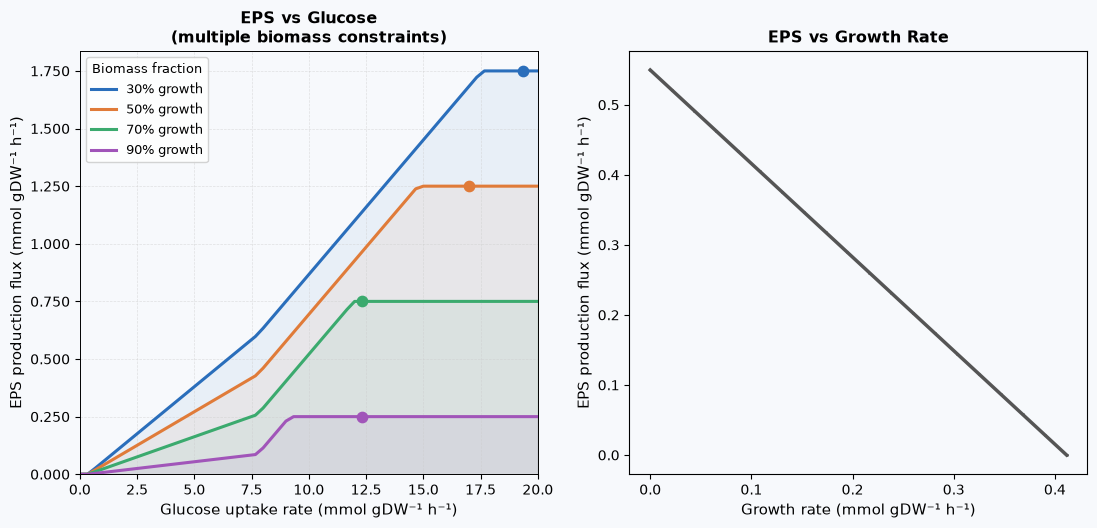

In [ ]:

import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
GLU_EXCHANGE_ID  = "EX_glc__D_e"   # glucose uptake exchange reaction ID
EPS_DEMAND_ID    = "DM_eps_c"       # EPS sink reaction ID
BIOMASS_RXN_ID   = "bio00006"  # ← change to your biomass reaction ID
                                     # (run: print([r.id for r in model_bs.reactions if "biomass" in r.id.lower()])
                                     #  to find yours)

BIOMASS_FRACTIONS = [0.3, 0.5, 0.7, 0.9]  # fractions of max growth to lock in
GLUCOSE_MAX       = 20.0   # mmol/gDW/h — upper end of scan
N_POINTS          = 61     # number of scan points

# Palette — one colour per biomass fraction
COLOURS = ["#2A6EBB", "#E07B39", "#3BAA6E", "#A155B9"]

glu_rxn     = model_bs_witheps.reactions.get_by_id(GLU_EXCHANGE_ID)
eps_rxn     = model_bs_witheps.reactions.get_by_id(EPS_DEMAND_ID)
biomass_rxn = model_bs_witheps.reactions.get_by_id(BIOMASS_RXN_ID)

glucose_range = np.linspace(0, GLUCOSE_MAX, N_POINTS)

# ─────────────────────────────────────────────────────────────────────────────
# SCAN
# ─────────────────────────────────────────────────────────────────────────────
print("Running biomass-constrained EPS scan...")
print(f"{'Biomass fraction':<20} {'Scan points':<14} {'Max EPS (mmol/gDW/h)'}")
print("─" * 58)

results = {}   # {fraction: np.array of EPS fluxes}

for fraction in BIOMASS_FRACTIONS:
    eps_vals    = []
    max_growth_vals = []

    for glu_uptake in glucose_range:
        with model_bs_witheps:
            glu_rxn.lower_bound = -glu_uptake

            # ── Step 1: maximise biomass ──────────────────────────────
            model_bs_witheps.objective = biomass_rxn
            sol_growth = model_bs_witheps.optimize()

            if sol_growth.status != "optimal" or sol_growth.objective_value <= 0:
                eps_vals.append(0.0)
                continue

            max_growth = sol_growth.objective_value

            # ── Step 2: constrain NET biomass (the actual obj expression)
            #           then maximise EPS ──────────────────────────────
            biomass_constraint = model_bs_witheps.problem.Constraint(
                model_bs_witheps.objective.expression,   # = bio00006 - bio00006_reverse_45381
                lb=fraction * max_growth,
                name="biomass_floor"
            )
            model_bs_witheps.add_cons_vars(biomass_constraint)

            model_bs_witheps.objective = eps_rxn
            sol_eps = model_bs_witheps.optimize()

            eps_vals.append(sol_eps.objective_value if sol_eps.status == "optimal" else 0.0)

    results[fraction] = np.array(eps_vals)
    peak = results[fraction].max()
    peak_glc = glucose_range[results[fraction].argmax()]
    print(f"  {fraction*100:.0f}% biomass         {N_POINTS:<14} "
          f"{peak:.4f}  (@ glc = {peak_glc:.1f})")

# ─────────────────────────────────────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1,2, figsize=(13, 5.5))
fig.patch.set_facecolor("#F7F9FC")

# ── Panel A: all fractions overlaid ──────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F7F9FC")

for (fraction, eps_vals), colour in zip(results.items(), COLOURS):
    ax1.plot(glucose_range, eps_vals,
             color=colour, linewidth=2.2, label=f"{int(fraction*100)}% growth")
    ax1.fill_between(glucose_range, eps_vals, alpha=0.07, color=colour)

    # Annotate peak
    peak_idx = np.argmax(eps_vals)
    if eps_vals[peak_idx] > 0:
        ax1.scatter(glucose_range[peak_idx], eps_vals[peak_idx],
                    color=colour, s=55, zorder=5)

ax1.set_xlabel("Glucose uptake rate (mmol gDW⁻¹ h⁻¹)", fontsize=10.5)
ax1.set_ylabel("EPS production flux (mmol gDW⁻¹ h⁻¹)", fontsize=10.5)
ax1.set_title("EPS vs Glucose\n(multiple biomass constraints)", fontsize=11.5,
              fontweight="bold")
ax1.legend(title="Biomass fraction", fontsize=9, title_fontsize=9,
           framealpha=0.85, loc="upper left")
ax1.set_xlim(0, GLUCOSE_MAX)
ax1.set_ylim(bottom=0)
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.55, color="#CCCCCC")
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
for spine in ax1.spines.values():
    spine.set_linewidth(0.7)

# ── Panel B: 90% fraction with saturation annotation ─────────────────────────
df= pd.read_csv("biomass_eps_tradeoff.csv")
ax2 = axes[1]
ax2.set_facecolor("#F7F9FC")


ax2.plot(df["flux_maximum"], df["DM_eps_c"], color="#555555", linewidth=2.5, zorder=3,marker="o", markersize=4, markerfacecolor="#888888", markeredgewidth=0.0)
#ax2.fill_between(df["glucose_uptake"], df["eps_production"], alpha=0.12, color=colour_90, zorder=2)
ax2.set_xlabel("Growth rate (mmol gDW⁻¹ h⁻¹)", fontsize=10.5)
ax2.set_ylabel("EPS production flux (mmol gDW⁻¹ h⁻¹)", fontsize=10.5)
ax2.set_title("EPS vs Growth Rate", fontsize=11.5,
              fontweight="bold")